In [7]:
# Notebook path setup (VS Code safe)
import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))


In [8]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

from src.io_utils import load_image_rgb, save_image_rgb
from src.kmeans_compress import kmeans_compress_rgb
from src.metrics import mse, psnr

## Load image

In [9]:
image_path = Path("../data/image_test_01.jpg")
img = load_image_rgb(image_path)
img.shape, img.min(), img.max()

((699, 1049, 3), np.float32(0.0), np.float32(1.0))

## Compresson on K=16

In [10]:
K = 16

result = kmeans_compress_rgb(img, k=K, random_state=42, n_init=10)
img_hat = result.reconstructed

mse_val = mse(img, img_hat)
psnr_val = psnr(img, img_hat, data_range=1.0)

print(f"K={K} | runtime={result.runtime_sec:.3f}s | MSE={mse_val:.6f} | PSNR={psnr_val:.2f} dB")

K=16 | runtime=9.344s | MSE=0.001518 | PSNR=28.19 dB


## Visualization

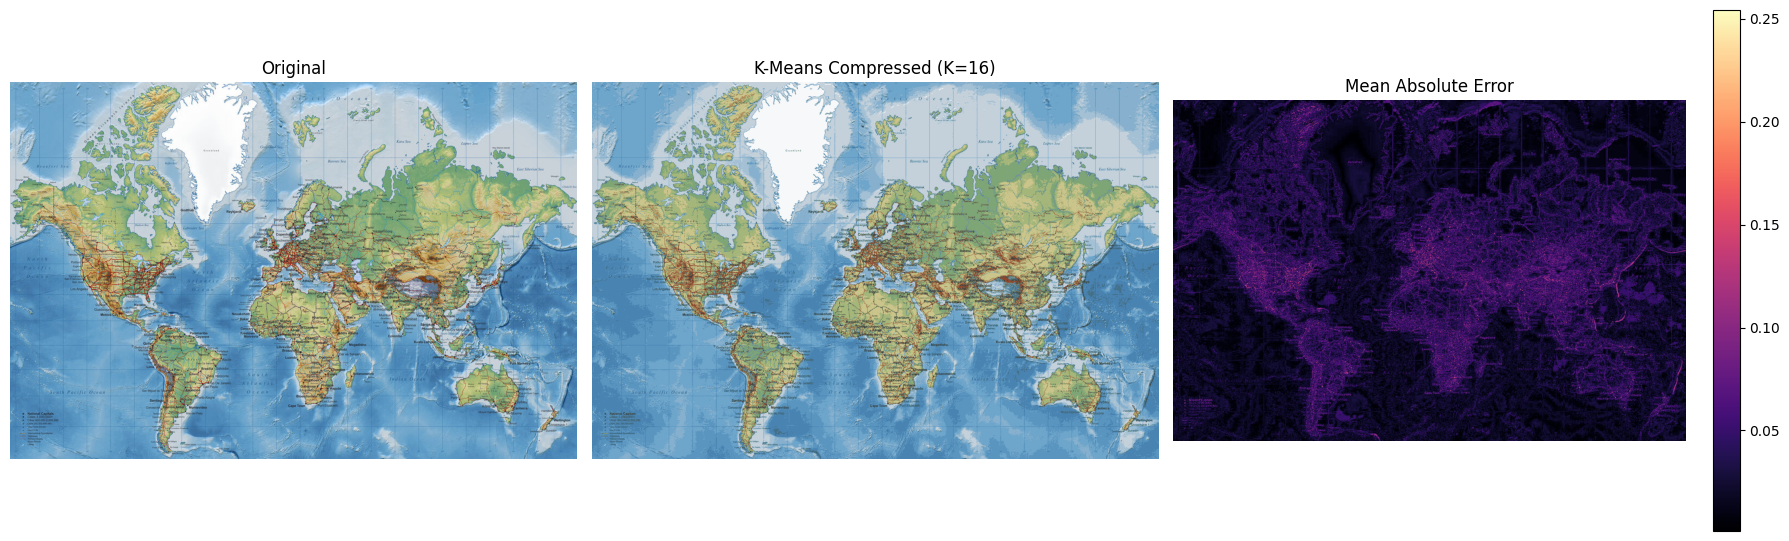

In [16]:
import numpy as np

error = np.abs(img - img_hat).mean(axis=2)

fig, axes = plt.subplots(1, 3, figsize=(18,6))
axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img_hat)
axes[1].set_title(f"K-Means Compressed (K={K})")
axes[1].axis("off")

im = axes[2].imshow(error, cmap="magma")
axes[2].set_title("Mean Absolute Error")
axes[2].axis("off")

fig.colorbar(im, ax=axes[2], fraction=0.046)
plt.tight_layout()
plt.show()

## Save outputs and log metrics

In [17]:
out_dir = Path("../outputs/baseline_rgb")
out_dir.mkdir(parents=True, exist_ok=True)

out_img_path = out_dir / f"{image_path.stem}_k{K}.png"
save_image_rgb(img_hat, out_img_path)

row = {
    "image": image_path.name,
    "k": K,
    "runtime_sec": result.runtime_sec,
    "mse": mse_val,
    "psnr_db": psnr_val,
}

metrics_path = out_dir / "metrics.csv"
df = pd.DataFrame([row])
if metrics_path.exists():
    df_prev = pd.read_csv(metrics_path)
    df = pd.concat([df_prev, df], ignore_index=True)

df.to_csv(metrics_path, index=False)
df.tail()

,image,k,runtime_sec,mse,psnr_db
0,image_test_01.jpg,16,9.344094,0.001518,28.188667
